# XGB Starter - [CV 26.4572]
Each Kaggle playground competition is synthetic data created from an original dataset. Kaggle's September Playground Competition is most likely created from an original dataset of random numbers explained [here][1].

None-the-less, the synthetic data generation process adds signal (explained [here][2] and [here][3]). This notebook shows some basic techniques to extract this synthetic data generation signal (as demonstrated in previous competition [here][4]). Specifically, we use 
* Float32 digit extraction
* Round numerical columns into bins
* Original data merged as new columns
* NVIDIA cuML's Target Encoder
* "Refit on Full" train data

Discussion about this notebook is [here][1]

[1]: https://www.kaggle.com/competitions/playground-series-s5e9/discussion/604028
[2]: https://www.kaggle.com/competitions/playground-series-s5e2/discussion/564056
[3]: https://www.kaggle.com/competitions/playground-series-s5e2/discussion/564486
[4]: https://www.kaggle.com/competitions/playground-series-s5e2/writeups/chris-deotte-1st-place-single-model-feature-engine

# Load Train, Test, Original

In [1]:
import pandas as pd, numpy as np

train = pd.read_csv("/kaggle/input/playground-series-s5e9/train.csv")
print("Train shape:", train.shape )
train.head()

Train shape: (524164, 11)


,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511


In [2]:
test = pd.read_csv("/kaggle/input/playground-series-s5e9/test.csv")
test['BeatsPerMinute'] = -1
print("Test shape:", test.shape )
test.head()

Test shape: (174722, 11)


,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,524164,0.410013,-16.794967,0.023500,0.232910,0.012689,0.271585,0.664321,302901.5498,0.424867,-1
1,524165,0.463071,-1.357000,0.141818,0.057725,0.257942,0.097624,0.829552,221995.6643,0.846000,-1
2,524166,0.686569,-3.368928,0.167851,0.287823,0.210915,0.325909,0.304978,357724.0127,0.134067,-1
3,524167,0.885793,-5.598049,0.118488,0.000005,0.376906,0.134435,0.487740,271790.3989,0.316467,-1
4,524168,0.637391,-7.068160,0.126099,0.539073,0.068950,0.024300,0.591248,277728.5383,0.481067,-1


In [3]:
orig = pd.read_csv("/kaggle/input/bpm-prediction-challenge/Train.csv")
print("Original data shape:", orig.shape )
orig.head()

Original data shape: (14633, 10)


,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0.513080,-7.811659,0.071013,0.064564,0.109495,0.316042,0.736929,328639.3188,0.556200,117.092439
1,0.775393,-6.819409,0.023500,0.510599,0.187498,0.024361,0.259488,271967.9826,0.410533,122.002279
2,0.636408,-19.782248,0.063451,0.427861,0.002226,0.024300,0.054848,186147.0029,0.533333,149.130616
3,0.232190,-14.957299,0.023500,0.076268,0.000001,0.228454,0.744650,321734.9723,0.658533,95.832178
4,0.758564,-4.715966,0.023500,0.263551,0.414794,0.197167,0.966592,179973.3982,0.230467,125.696263


In [4]:
combine = pd.concat([train,test,orig],axis=0,ignore_index=True)
print("Combine shape:", combine.shape )
combine.head()

Combine shape: (713519, 11)


,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0.0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,1.0,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,2.0,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,3.0,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,4.0,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511


# Feature Engineer
For feature engineering we use
* Float32 digit extraction
* Round numerical columns into bins
* Original data merged as new columns
* NVIDIA cuML's Target Encoder (during KFold for-loop)

In [5]:
FEATURES = list( orig.columns[:-1] )
TARGET = orig.columns[-1]
print(f"Features: {FEATURES}, Target: ''{TARGET}''")

Features: ['RhythmScore', 'AudioLoudness', 'VocalContent', 'AcousticQuality', 'InstrumentalScore', 'LivePerformanceLikelihood', 'MoodScore', 'TrackDurationMs', 'Energy'], Target: ''BeatsPerMinute''


In [6]:
DIGITS = []
for c in ['Energy','MoodScore','AcousticQuality']:
    for k in range(1,10):
        n = f'{c}_d{k}'
        combine[n] = ((combine[c] * 10**k) % 10).fillna(-1).astype("int8")
        DIGITS.append(n)

In [7]:
ROUND = []
RR = [9,8]
for c in FEATURES:
    print(f"{c}, ",end="")
    for r in RR:
        n = f"{c}_r{r}"
        combine[n] = combine[c].round(r)
        ROUND.append(n)

RhythmScore, AudioLoudness, VocalContent, AcousticQuality, InstrumentalScore, LivePerformanceLikelihood, MoodScore, TrackDurationMs, Energy, 

In [8]:
train = combine.iloc[:len(train)]
test = combine.iloc[len(train):len(train)+len(test)]
orig = combine.iloc[-len(orig):]
print(f"Train shape: {train.shape}, Test shape: {test.shape}, Original data shape: {orig.shape}")

Train shape: (524164, 56), Test shape: (174722, 56), Original data shape: (14633, 56)


In [9]:
TE = []
print(f"Processing {len(FEATURES+ROUND)} features... ",end="")
for c in FEATURES+ROUND:
    tmp = orig.groupby(c)[TARGET].mean()
    n = f"TE0_{c}"
    print(f"{n}, ",end="")
    tmp.name = n
    train = train.merge(tmp, on=c, how='left')
    test = test.merge(tmp, on=c, how='left')
    TE.append(n)

Processing 27 features... TE0_RhythmScore, TE0_AudioLoudness, TE0_VocalContent, TE0_AcousticQuality, TE0_InstrumentalScore, TE0_LivePerformanceLikelihood, TE0_MoodScore, TE0_TrackDurationMs, TE0_Energy, TE0_RhythmScore_r9, TE0_RhythmScore_r8, TE0_AudioLoudness_r9, TE0_AudioLoudness_r8, TE0_VocalContent_r9, TE0_VocalContent_r8, TE0_AcousticQuality_r9, TE0_AcousticQuality_r8, TE0_InstrumentalScore_r9, TE0_InstrumentalScore_r8, TE0_LivePerformanceLikelihood_r9, TE0_LivePerformanceLikelihood_r8, TE0_MoodScore_r9, TE0_MoodScore_r8, TE0_TrackDurationMs_r9, TE0_TrackDurationMs_r8, TE0_Energy_r9, TE0_Energy_r8, 

# Train XGBoost
During each KFold for-loop iteration, we use NVIDIA cuML's Target Encoder to generate more features for us.

In [10]:
from cuml.preprocessing import TargetEncoder
from sklearn.model_selection import KFold
import xgboost as xgb

print(f"XGBoost version {xgb.__version__}")

XGBoost version 2.0.3


In [11]:
FOLDS = 7
SEED = 42

params = {
    "objective": "reg:squarederror",   
    "eval_metric": "rmse",             
    "learning_rate": 0.002,
    "max_depth": 5,                    
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "seed": SEED,
    "device": "cuda",
}

In [12]:
oof_preds = np.zeros(len(train))
test_preds = np.zeros(len(test))

kf = KFold(n_splits=FOLDS, shuffle=True, random_state=SEED)
for fold, (train_idx, val_idx) in enumerate(kf.split(train)):
    print("#"*25)
    print(f"### Fold {fold+1} ###")
    print("#"*25)

    X_train = train.iloc[train_idx][FEATURES+TE+ROUND+DIGITS].copy()
    y_train = train.iloc[train_idx][TARGET]
    
    X_valid = train.iloc[val_idx][FEATURES+TE+ROUND+DIGITS].copy()
    y_valid = train.iloc[val_idx][TARGET]
    X_test = test[FEATURES+TE+ROUND+DIGITS].copy()

    CC = FEATURES+ROUND
    print(f"Target encoding {len(CC)} features... ",end="")
    for i,c in enumerate(CC):
        if i%5==0: print(f"{i}, ",end="")
        n = f"TE_{c}"
        TE0 = TargetEncoder(n_folds=10, smooth=4, split_method='random', stat='mean')
        X_train[n] = TE0.fit_transform(X_train[c],y_train).astype('float32')
        X_valid[n] = TE0.transform(X_valid[c]).astype('float32')
        X_test[n] = TE0.transform(X_test[c]).astype('float32')            
    print()

    dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=False)
    dval   = xgb.DMatrix(X_valid, label=y_valid, enable_categorical=False)
    dtest  = xgb.DMatrix(X_test, enable_categorical=False)

    model = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=10_000,
        evals=[(dtrain, "train"), (dval, "valid")],
        early_stopping_rounds=200,
        verbose_eval=200
    )

    oof_preds[val_idx] = model.predict(dval, iteration_range=(0, model.best_iteration + 1))
    test_preds += model.predict(dtest, iteration_range=(0, model.best_iteration + 1)) / FOLDS

#########################
### Fold 1 ###
#########################
Target encoding 27 features... 0, 5, 10, 15, 20, 25, 
[0]	train-rmse:26.46517	valid-rmse:26.48490
[200]	train-rmse:26.45278	valid-rmse:26.48007
[400]	train-rmse:26.44343	valid-rmse:26.47758
[600]	train-rmse:26.43521	valid-rmse:26.47635
[800]	train-rmse:26.42733	valid-rmse:26.47587
[1000]	train-rmse:26.41962	valid-rmse:26.47548
[1200]	train-rmse:26.41210	valid-rmse:26.47521
[1400]	train-rmse:26.40461	valid-rmse:26.47493
[1600]	train-rmse:26.39733	valid-rmse:26.47479
[1800]	train-rmse:26.39021	valid-rmse:26.47473
[2000]	train-rmse:26.38319	valid-rmse:26.47470
[2200]	train-rmse:26.37623	valid-rmse:26.47469
[2400]	train-rmse:26.36938	valid-rmse:26.47459
[2600]	train-rmse:26.36267	valid-rmse:26.47461
[2700]	train-rmse:26.35931	valid-rmse:26.47460
#########################
### Fold 2 ###
#########################
Target encoding 27 features... 0, 5, 10, 15, 20, 25, 
[0]	train-rmse:26.47796	valid-rmse:26.40798
[200]	train-rmse

# CV Score

In [13]:
m = np.sqrt( np.mean( (oof_preds - train[TARGET].values)**2. ) )
print(f" Overall CV RMSE = {m}")

 Overall CV RMSE = 26.457253672391232


# XGB Feature Importance

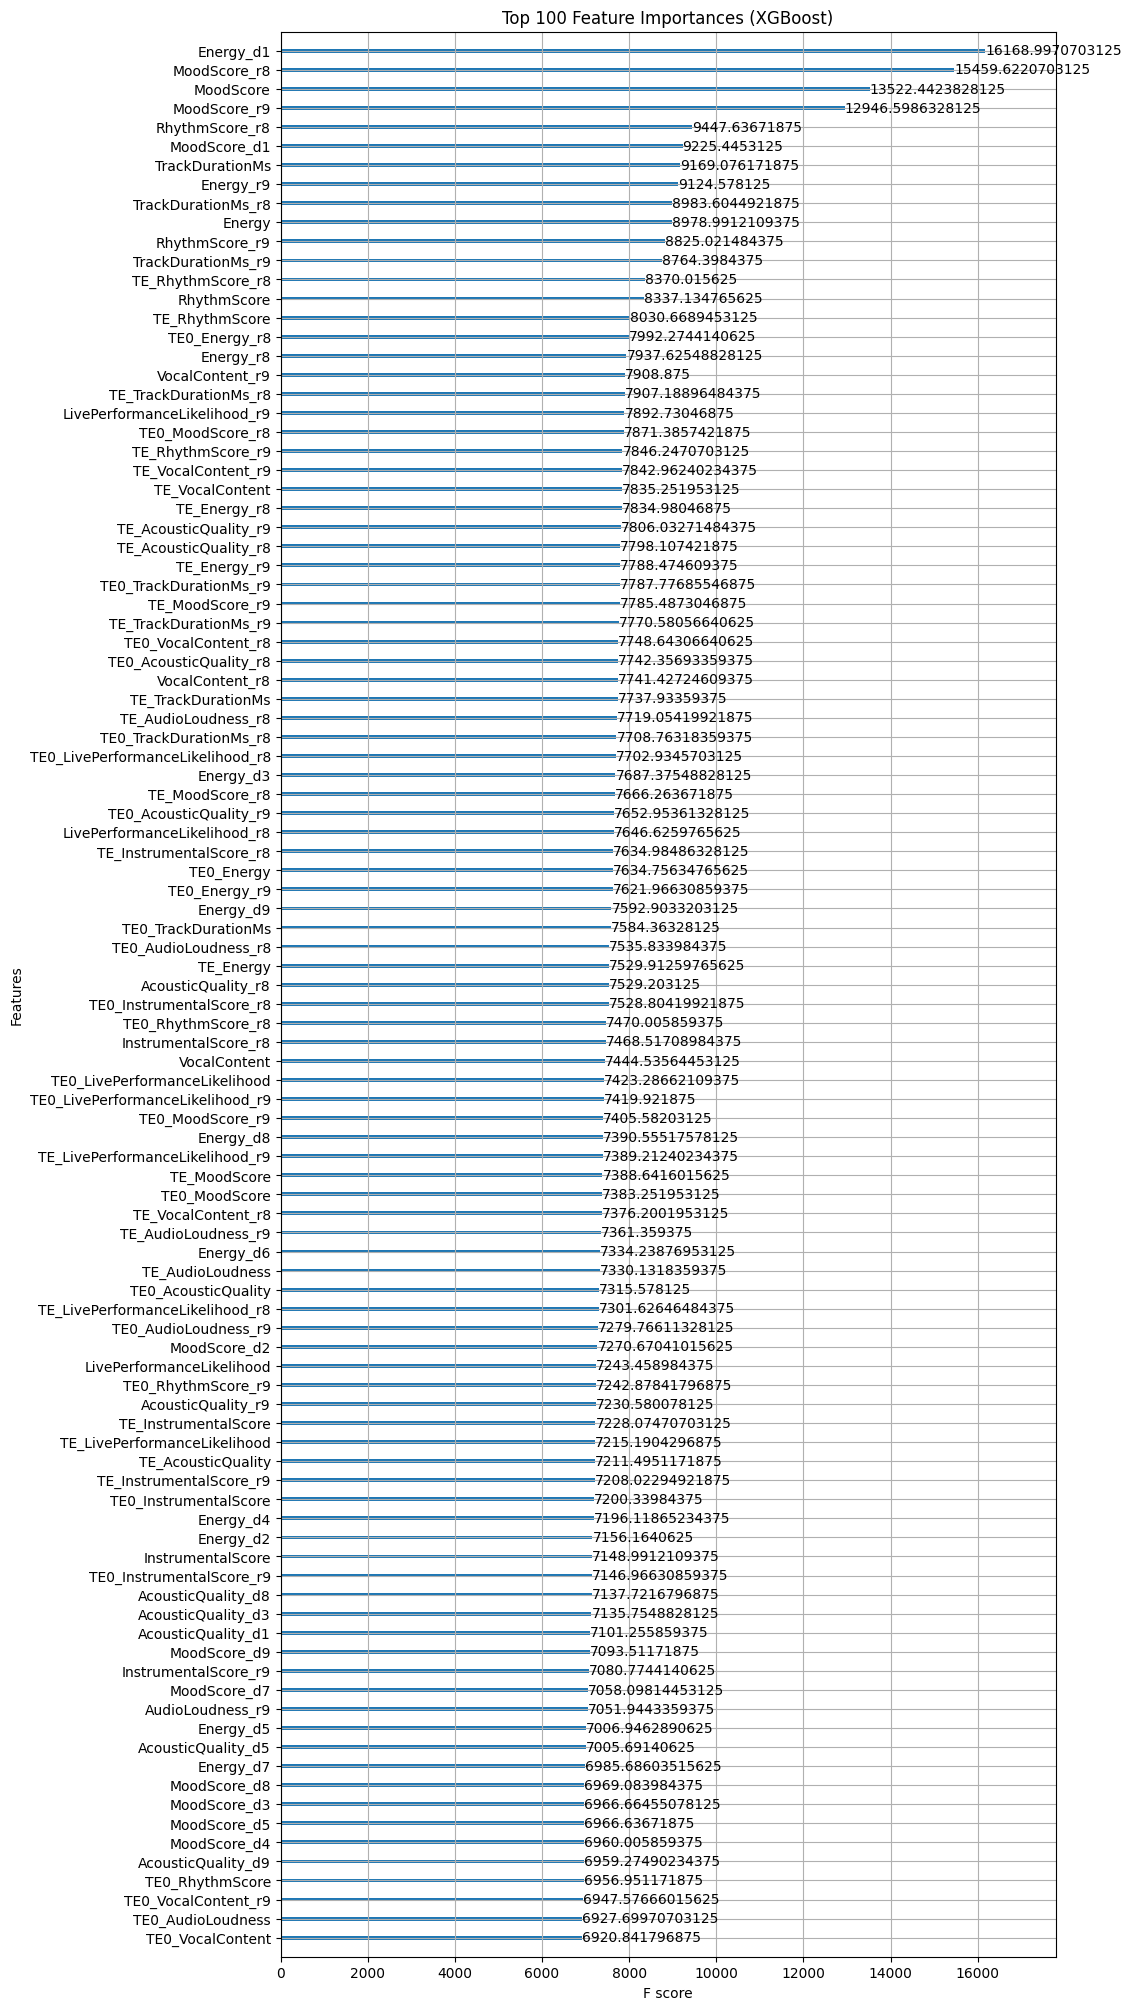

In [14]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 25))
xgb.plot_importance(model, max_num_features=100, importance_type='gain',ax=ax)
plt.title("Top 100 Feature Importances (XGBoost)")
plt.show()

# Create Submission CSV

In [15]:
sub = pd.read_csv("/kaggle/input/playground-series-s5e9/sample_submission.csv")
sub.BeatsPerMinute = test_preds
sub.to_csv("submission.csv",index=False)
sub.head()

,id,BeatsPerMinute
0,524164,118.962860
1,524165,118.460688
2,524166,119.206980
3,524167,119.525236
4,524168,119.002663


# Refit on Full
We new use a technique to boost LB score called "refit on full" explained [here][1]. When training 7 KFold above with early stopping, the optimal number of iterations for each KFold was `2700, 2232, 2652, 2000, 2327, 2288, 1842` respectively. The average is `2292`. Also `early_stopping_rounds=200`, so the average is actually `2092`.

When training with 100% train data (i.e. refit on full), we need to use `K/(K-1)` more iterations. So we use `7/6 * 2092 = 2440`. We will now train with 100% train data using fixed `2440` iterations.

[1]: https://www.kaggle.com/competitions/playground-series-s5e8/discussion/601015

In [16]:
test_preds_full = np.zeros(len(test))

kf = KFold(n_splits=FOLDS, shuffle=True, random_state=SEED)
for fold, (train_idx, val_idx) in enumerate(kf.split(train)):
    print("#"*25)
    print(f"### Fold {fold+1} ###")
    print("#"*25)

    # WE NOW USE 100% TRAIN HERE
    X_train = train[FEATURES+TE+ROUND+DIGITS].copy()
    y_train = train[TARGET]
    
    X_valid = train.iloc[val_idx][FEATURES+TE+ROUND+DIGITS].copy()
    y_valid = train.iloc[val_idx][TARGET]
    X_test = test[FEATURES+TE+ROUND+DIGITS].copy()

    CC = FEATURES+ROUND
    print(f"Target encoding {len(CC)} features... ",end="")
    for i,c in enumerate(CC):
        if i%5==0: print(f"{i}, ",end="")
        n = f"TE_{c}"
        TE0 = TargetEncoder(n_folds=10, smooth=4, split_method='random', stat='mean')
        X_train[n] = TE0.fit_transform(X_train[c],y_train).astype('float32')
        X_valid[n] = TE0.transform(X_valid[c]).astype('float32')
        X_test[n] = TE0.transform(X_test[c]).astype('float32')            
    print()

    dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=False)
    dval   = xgb.DMatrix(X_valid, label=y_valid, enable_categorical=False)
    dtest  = xgb.DMatrix(X_test, enable_categorical=False)

    # WE CHANGE SEED EACH FOLD AND USE FIXED 2440 ITERATIONS
    params['seed'] = fold
    model = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=2440,
        evals=[(dtrain, "train"), (dval, "valid")],
        verbose_eval=200
    )

    test_preds_full += model.predict(dtest) / FOLDS

#########################
### Fold 1 ###
#########################
Target encoding 27 features... 0, 5, 10, 15, 20, 25, 
[0]	train-rmse:26.46798	valid-rmse:26.48452
[200]	train-rmse:26.45629	valid-rmse:26.42181
[400]	train-rmse:26.44767	valid-rmse:26.37820
[600]	train-rmse:26.44035	valid-rmse:26.33579
[800]	train-rmse:26.43326	valid-rmse:26.29731
[1000]	train-rmse:26.42640	valid-rmse:26.26710
[1200]	train-rmse:26.41977	valid-rmse:26.24009
[1400]	train-rmse:26.41326	valid-rmse:26.21752
[1600]	train-rmse:26.40699	valid-rmse:26.19994
[1800]	train-rmse:26.40083	valid-rmse:26.18773
[2000]	train-rmse:26.39469	valid-rmse:26.17206
[2200]	train-rmse:26.38863	valid-rmse:26.15679
[2400]	train-rmse:26.38269	valid-rmse:26.14981
[2439]	train-rmse:26.38157	valid-rmse:26.14849
#########################
### Fold 2 ###
#########################
Target encoding 27 features... 0, 5, 10, 15, 20, 25, 
[0]	train-rmse:26.46798	valid-rmse:26.40747
[200]	train-rmse:26.45624	valid-rmse:26.34729
[400]	train-rmse:

In [17]:
sub.BeatsPerMinute = test_preds_full
sub.to_csv("submission_refit_full.csv",index=False)
sub.head()

,id,BeatsPerMinute
0,524164,118.919777
1,524165,118.328476
2,524166,119.117729
3,524167,119.295235
4,524168,119.104605
